/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


Warning from atmosphericRadiationDoseAndFlux module: currently using an alpha particle as input actually calculates the contribution from alpha + all simulated heavier ions, rather than just alpha particles!
Loading edose response data for protons...
Response array shape: (137, 50)
Energy range: 11.29 - 8.97e+05 MeV
Altitude range: 0.025 - 80.0 km
Number of zero/negative values: 668

Response values at approximately 40,000 ft (12.2 km):
Actual altitude: 12.20 km

Energy (GeV/nucleon) | Response (pSv·cm²/particle)
--------------------------------------------------
             0.1 |                       4.89e-04
             0.5 |                       2.44e-01
             1.0 |                       2.27e+00
             5.0 |                       1.28e+01

Generating energy response plot...


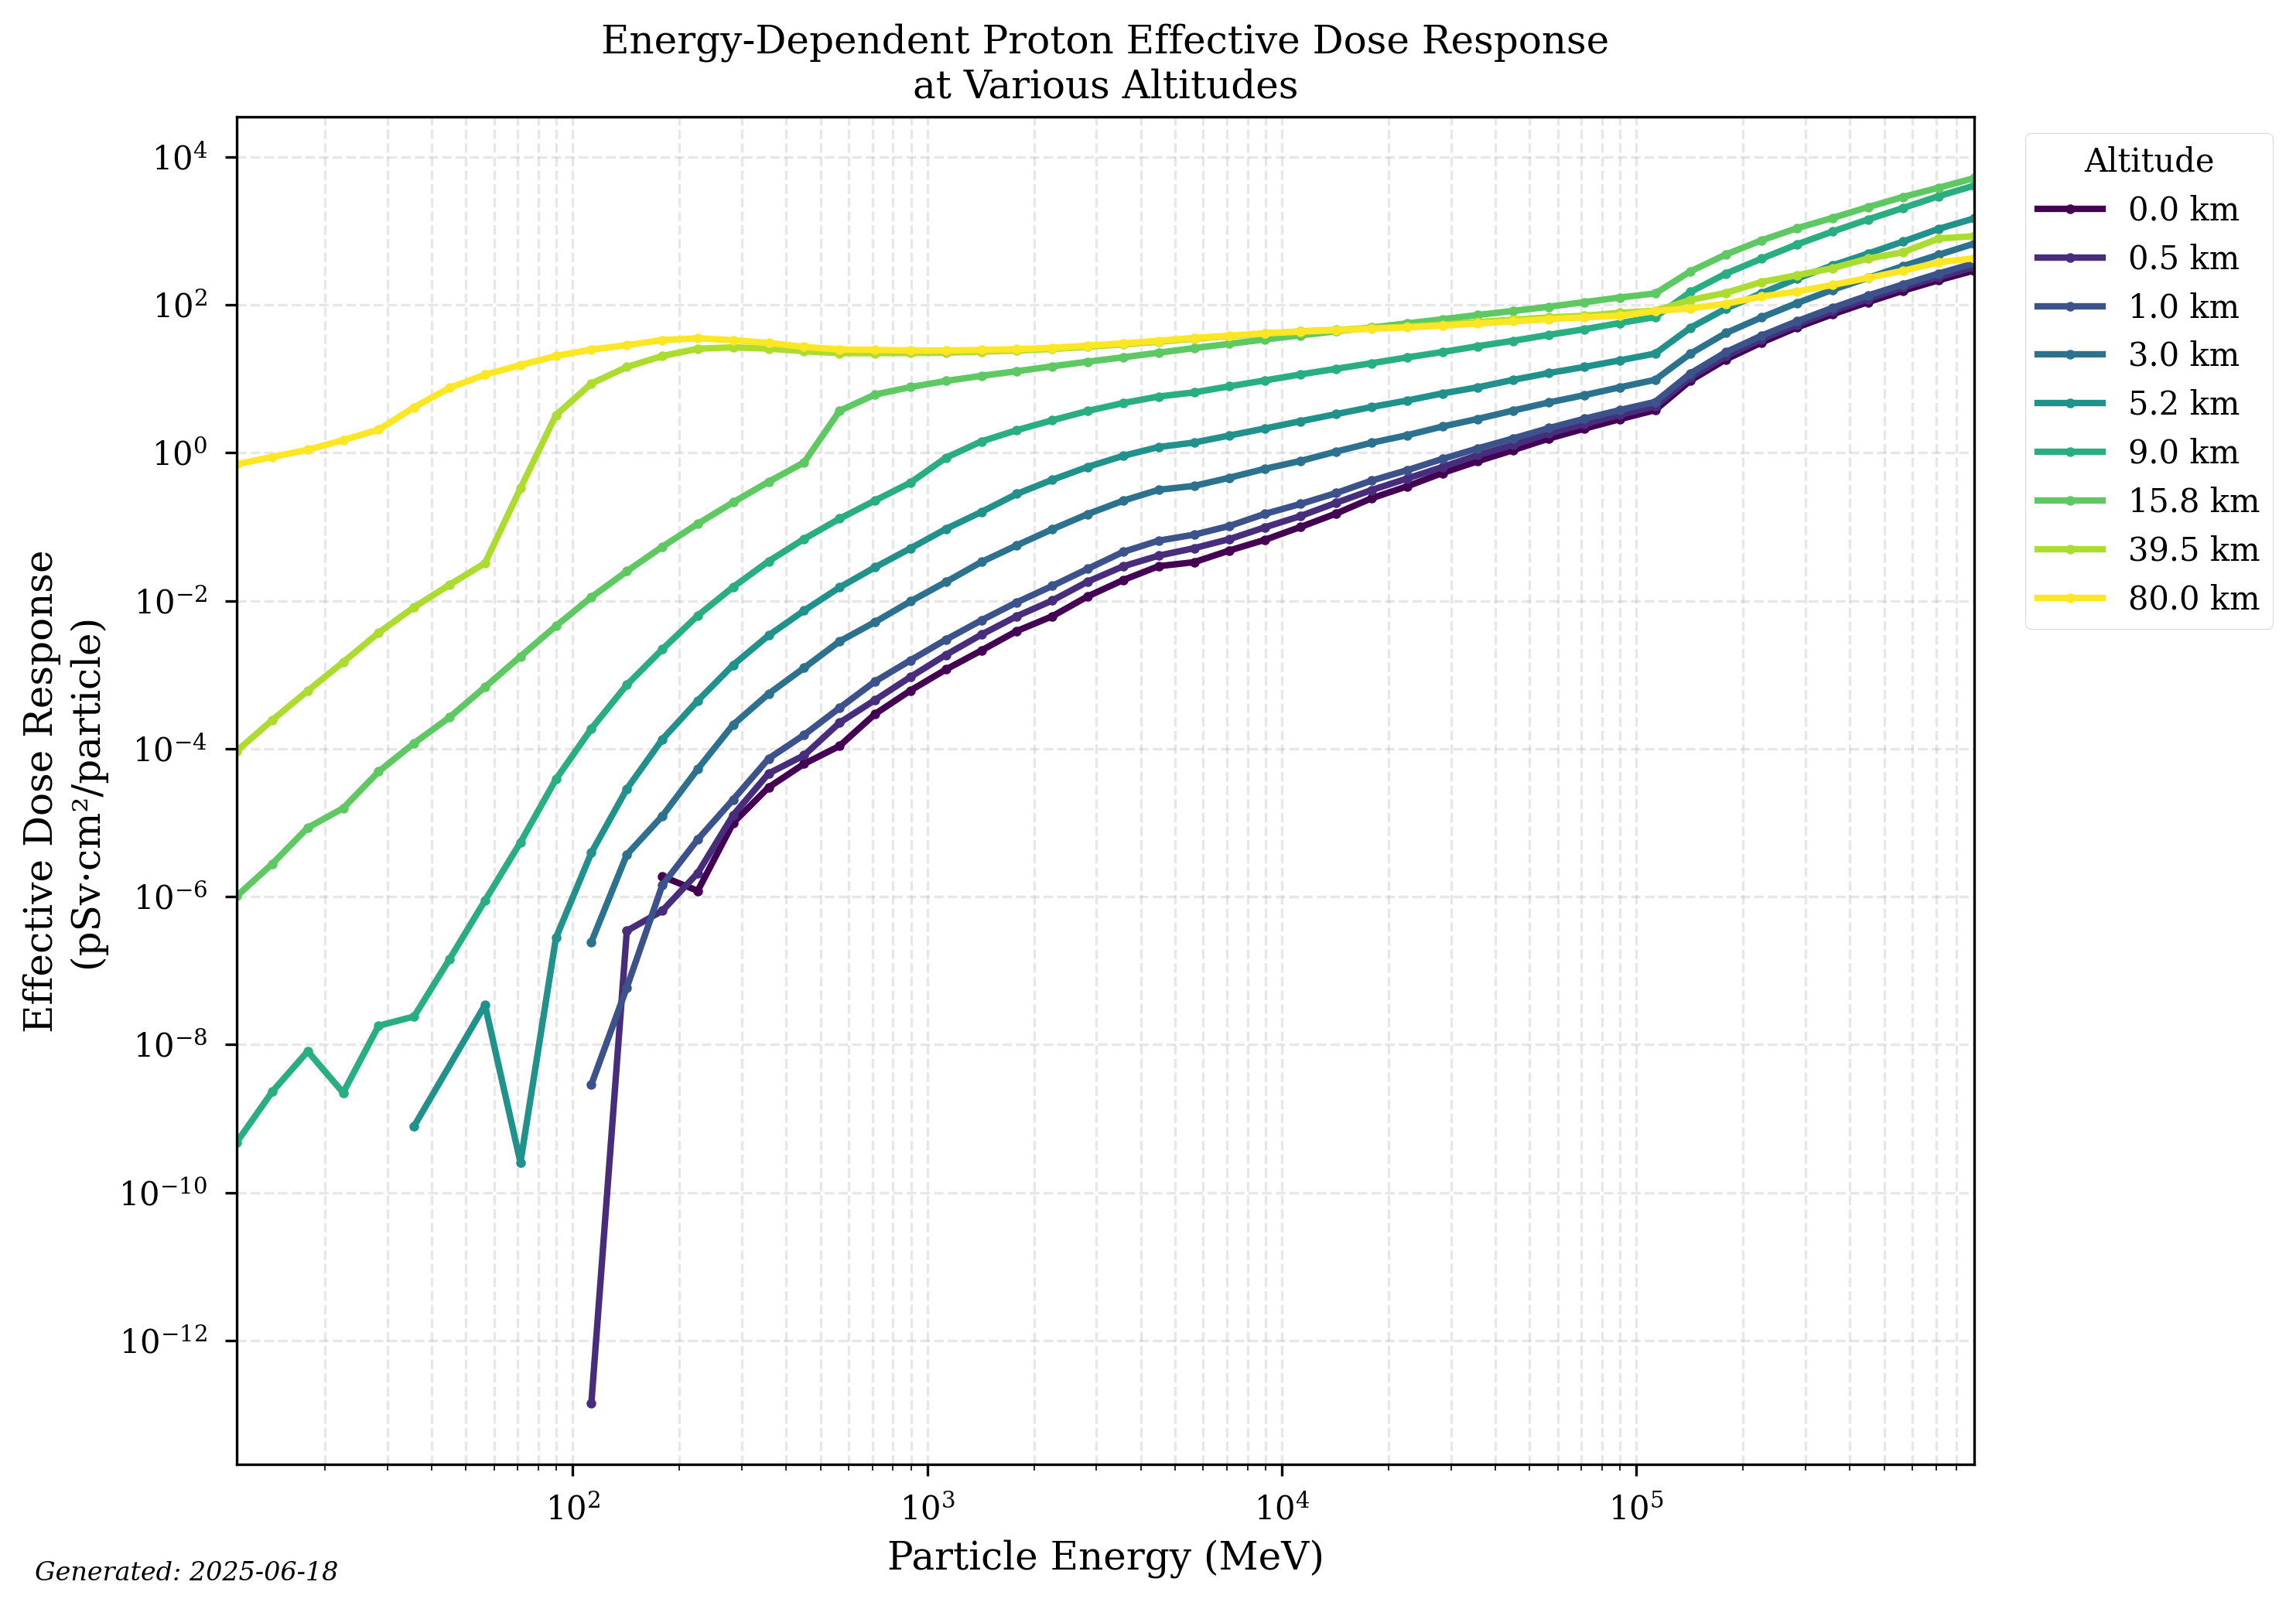

Generating altitude response plot...


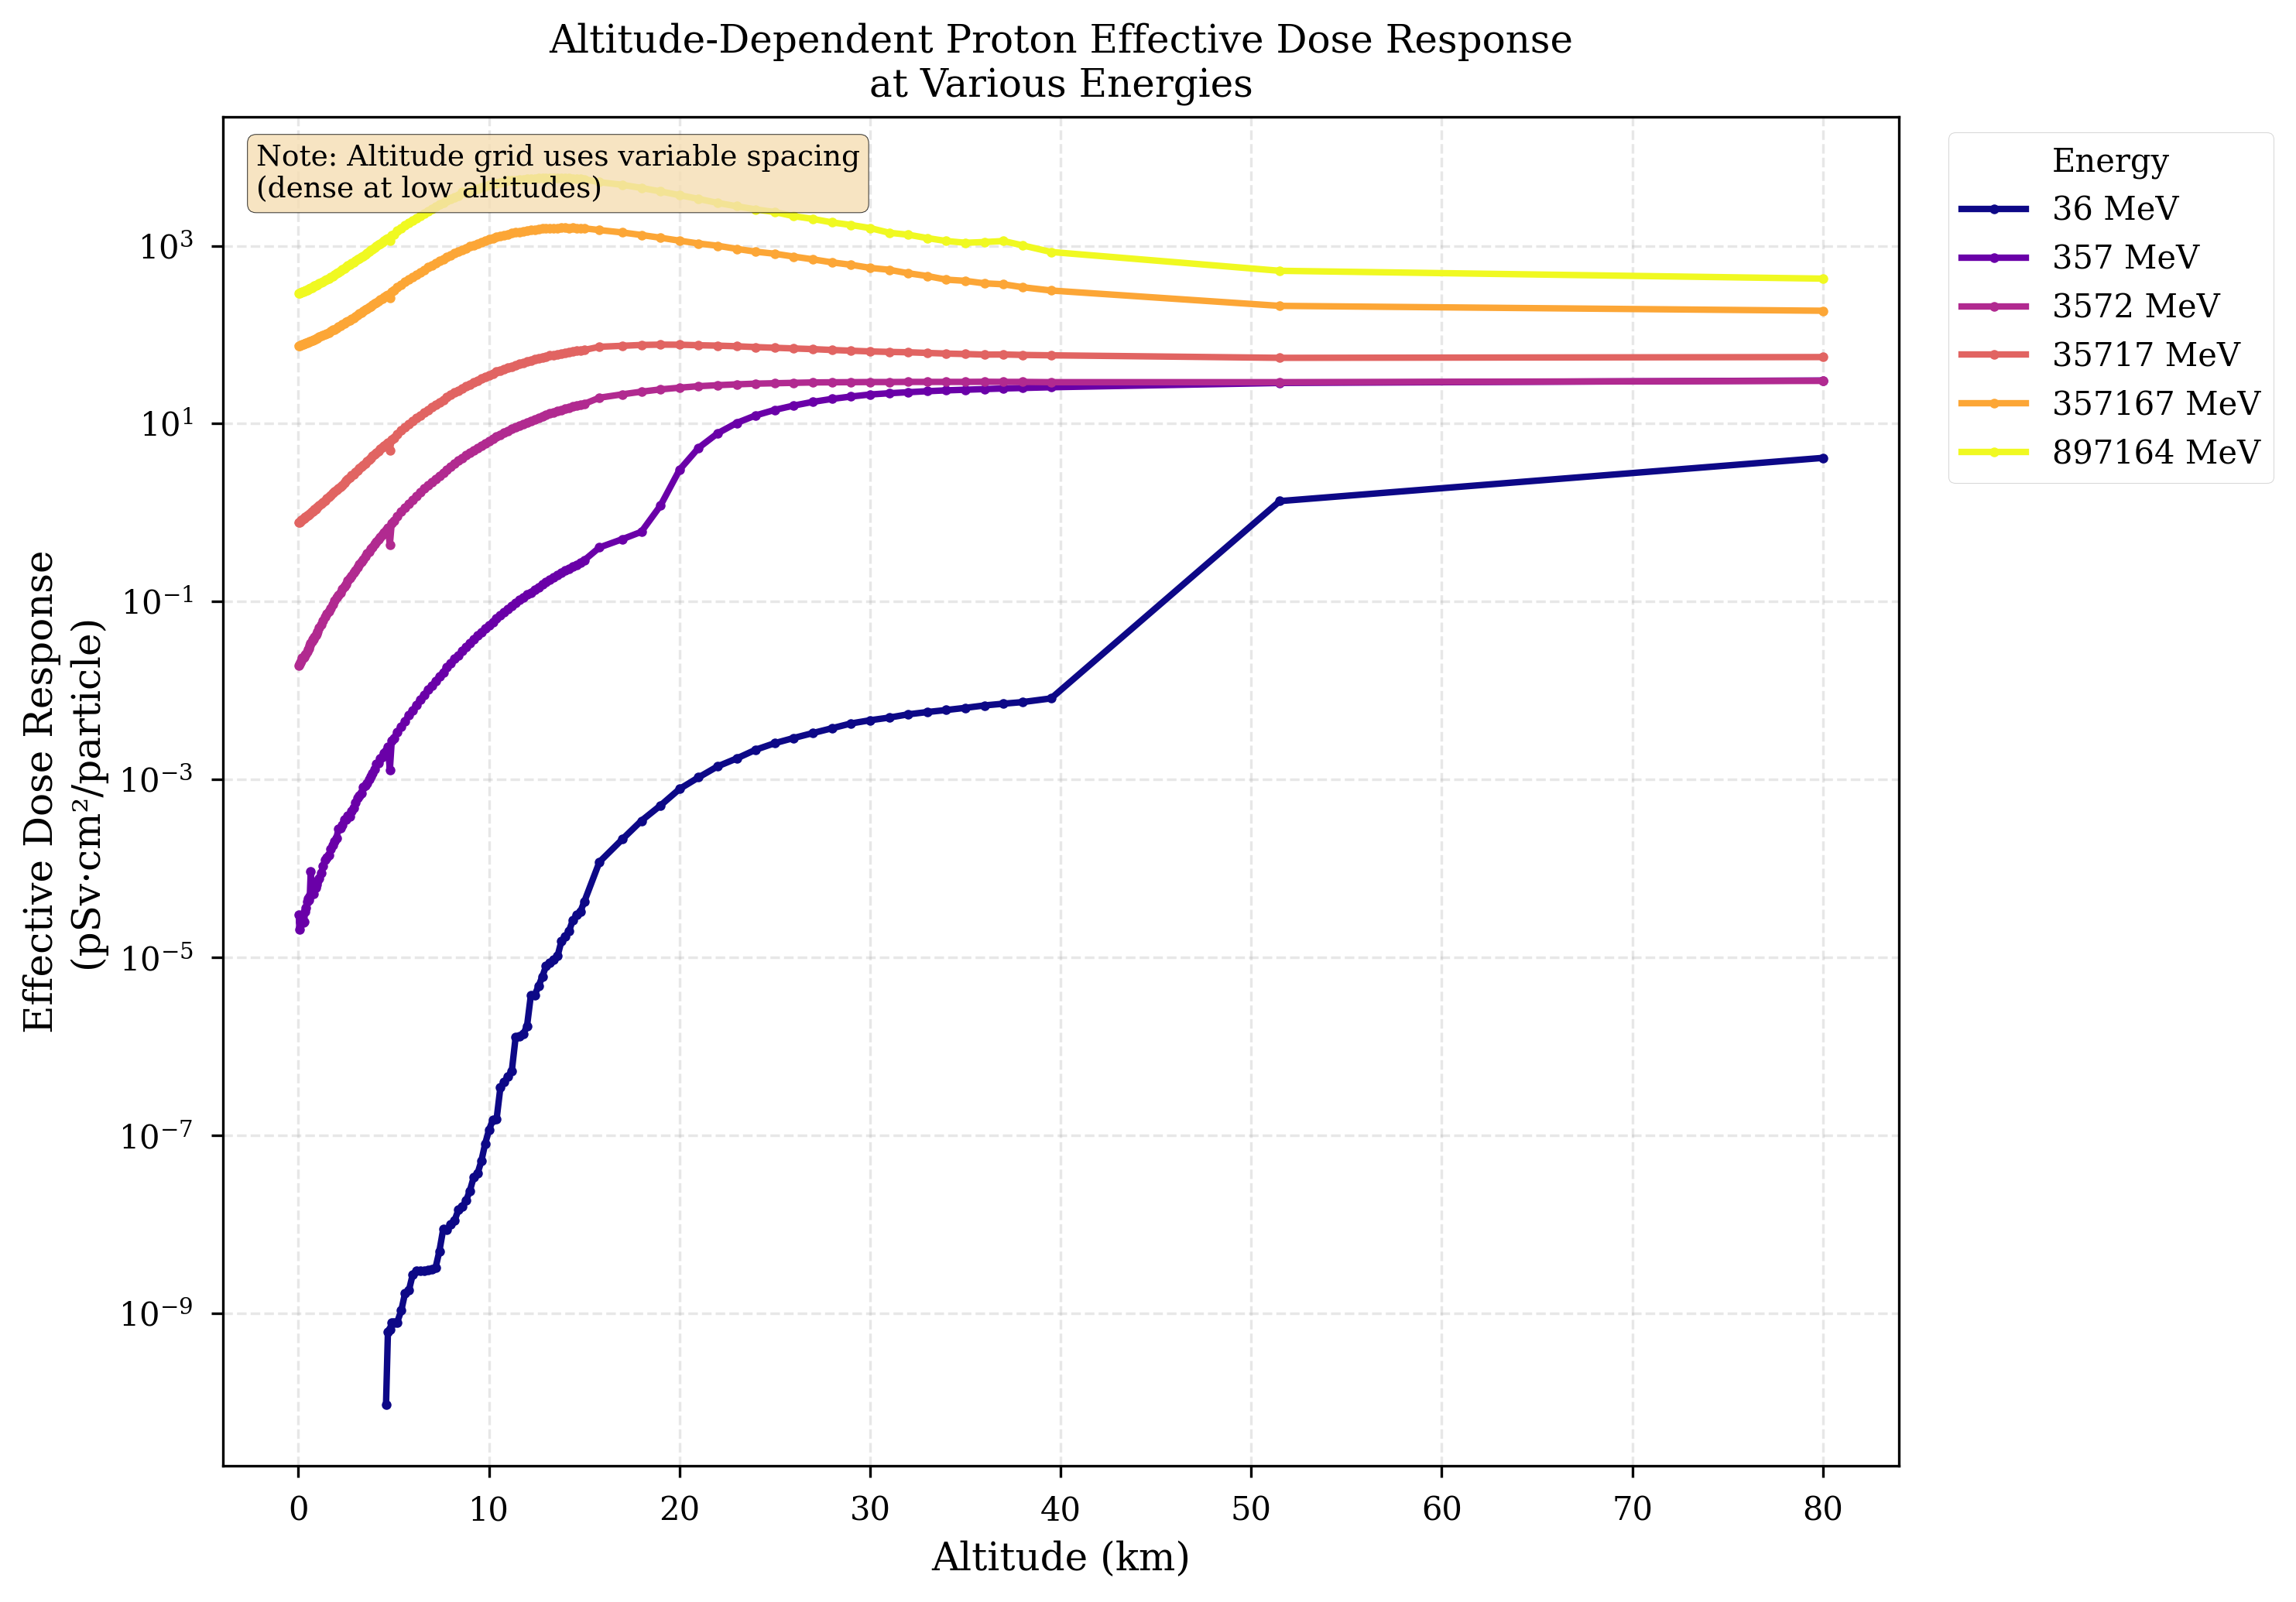

Generating response heatmap...


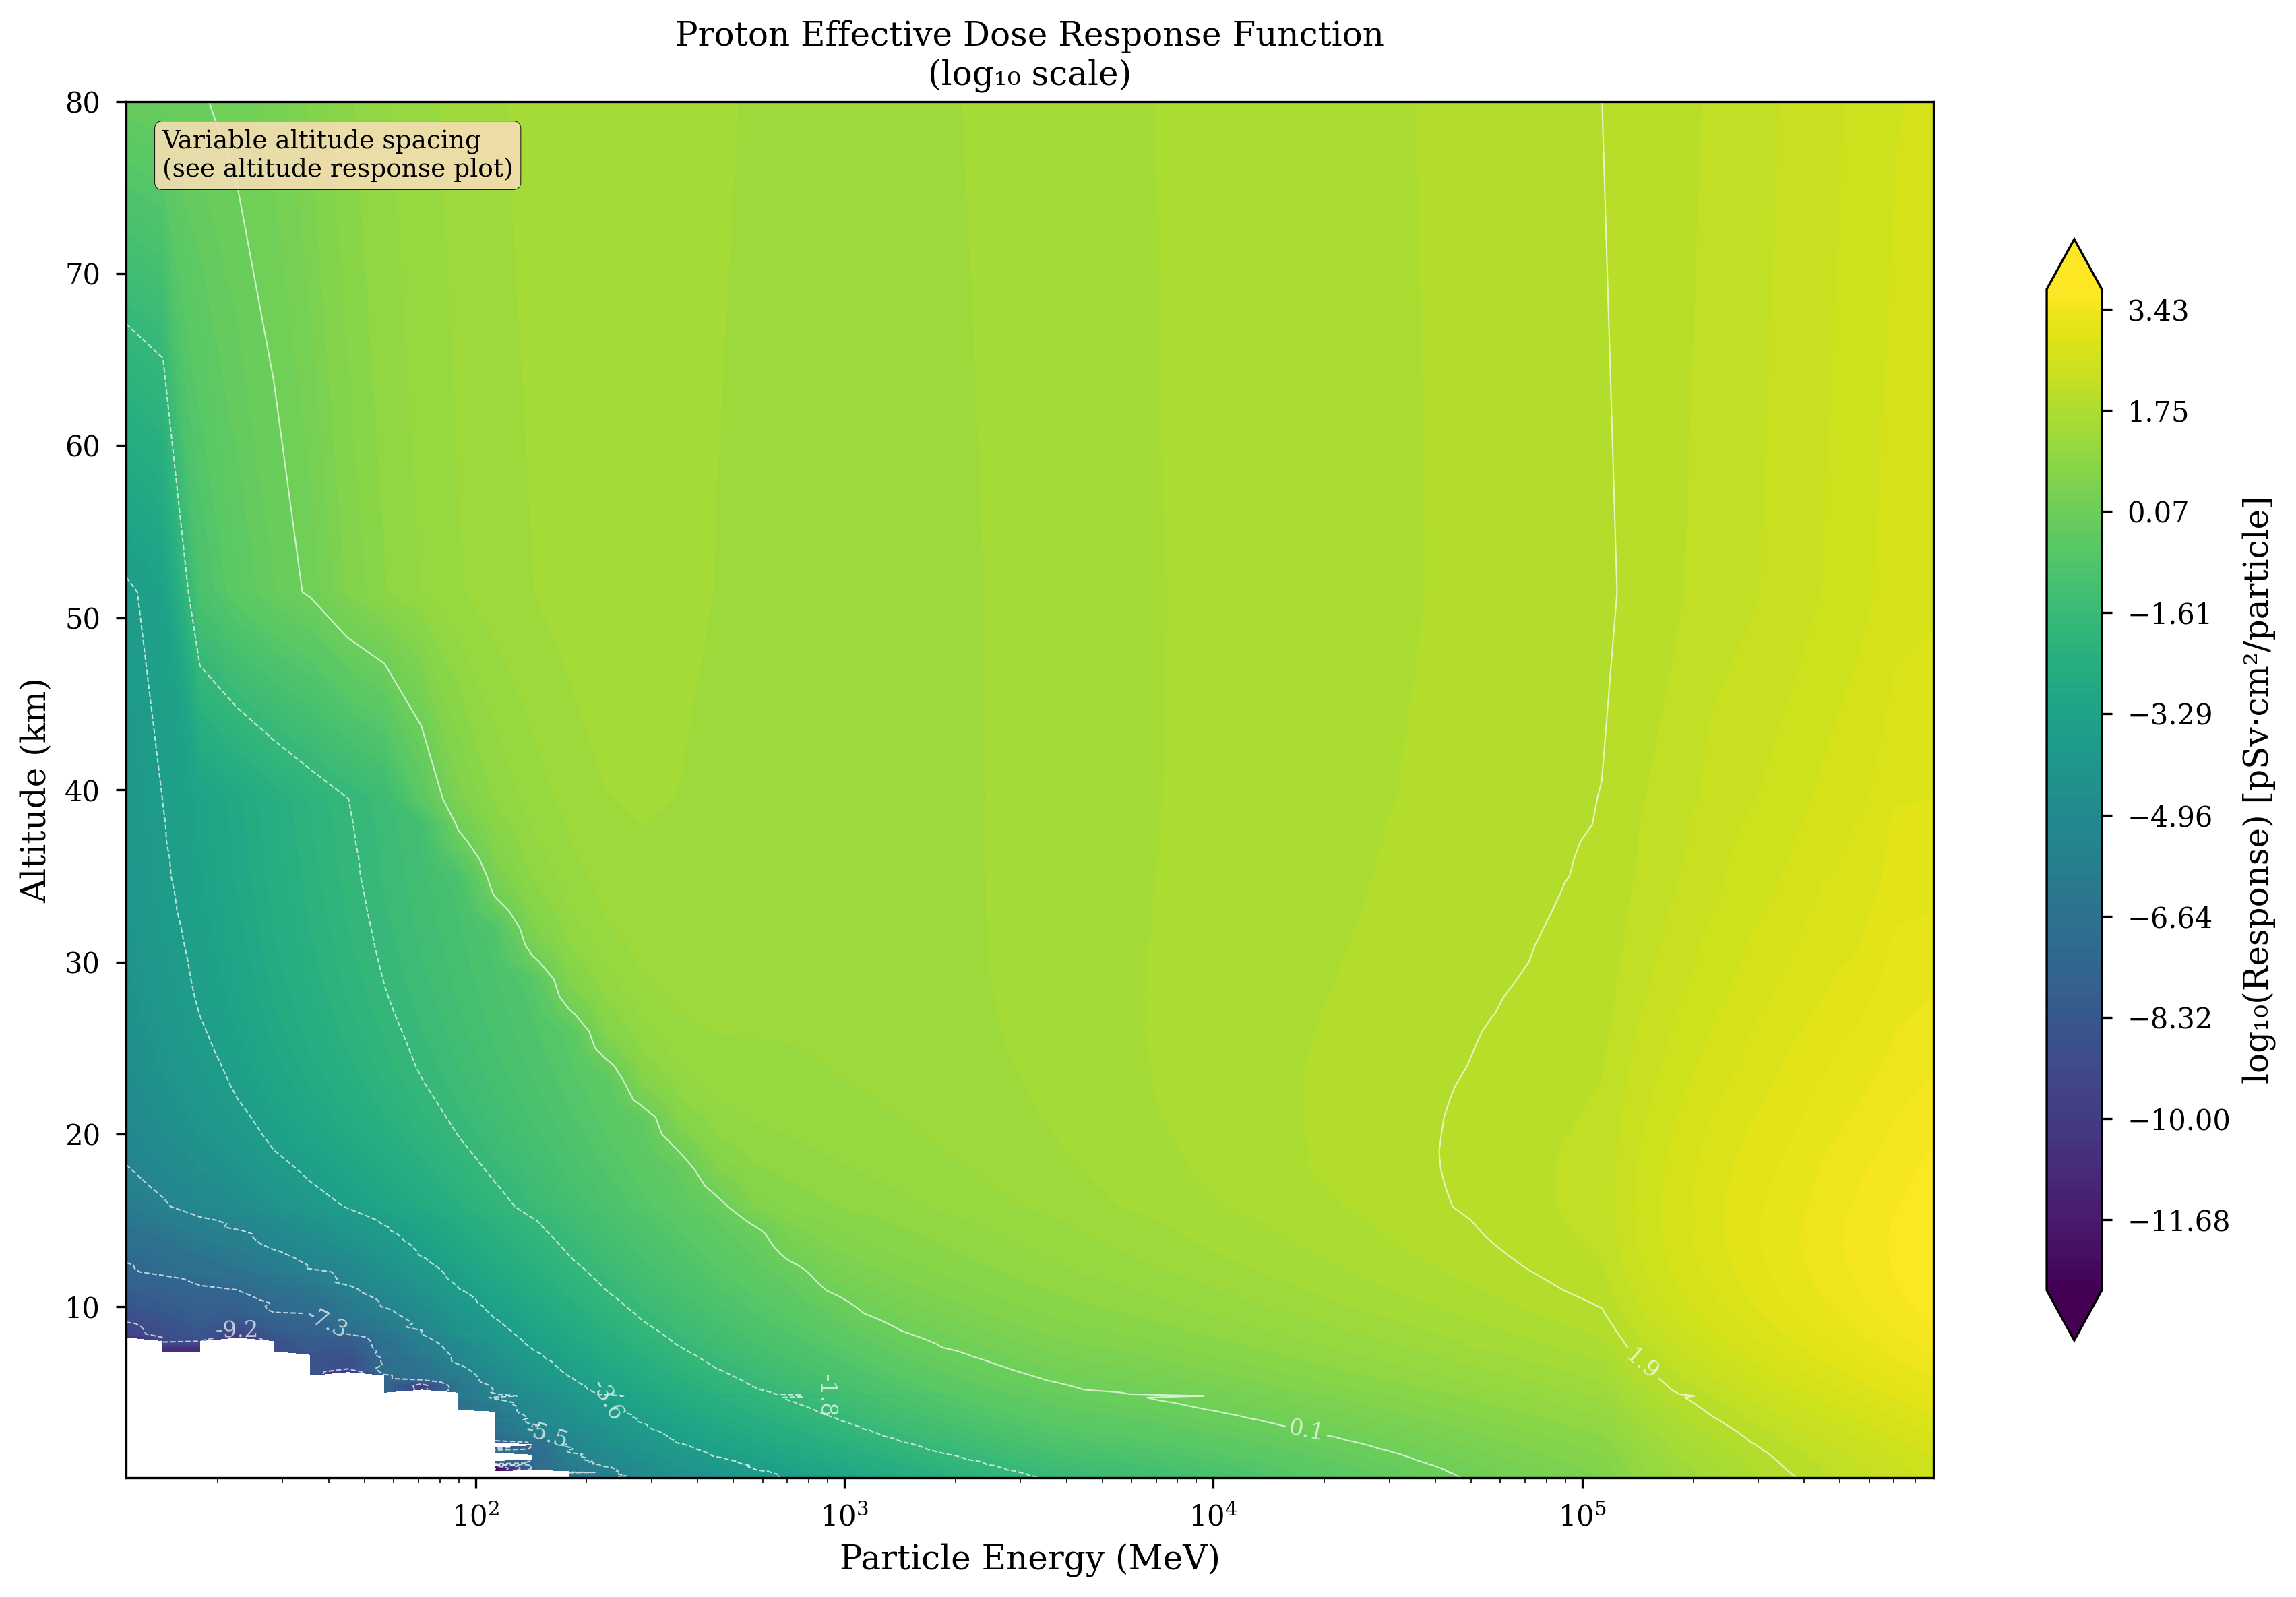

Generating integrated response plots...


/tmp/ipykernel_268035/1919239996.py:251: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_response[alt_idx] = np.trapz(response_valid, energy_valid)


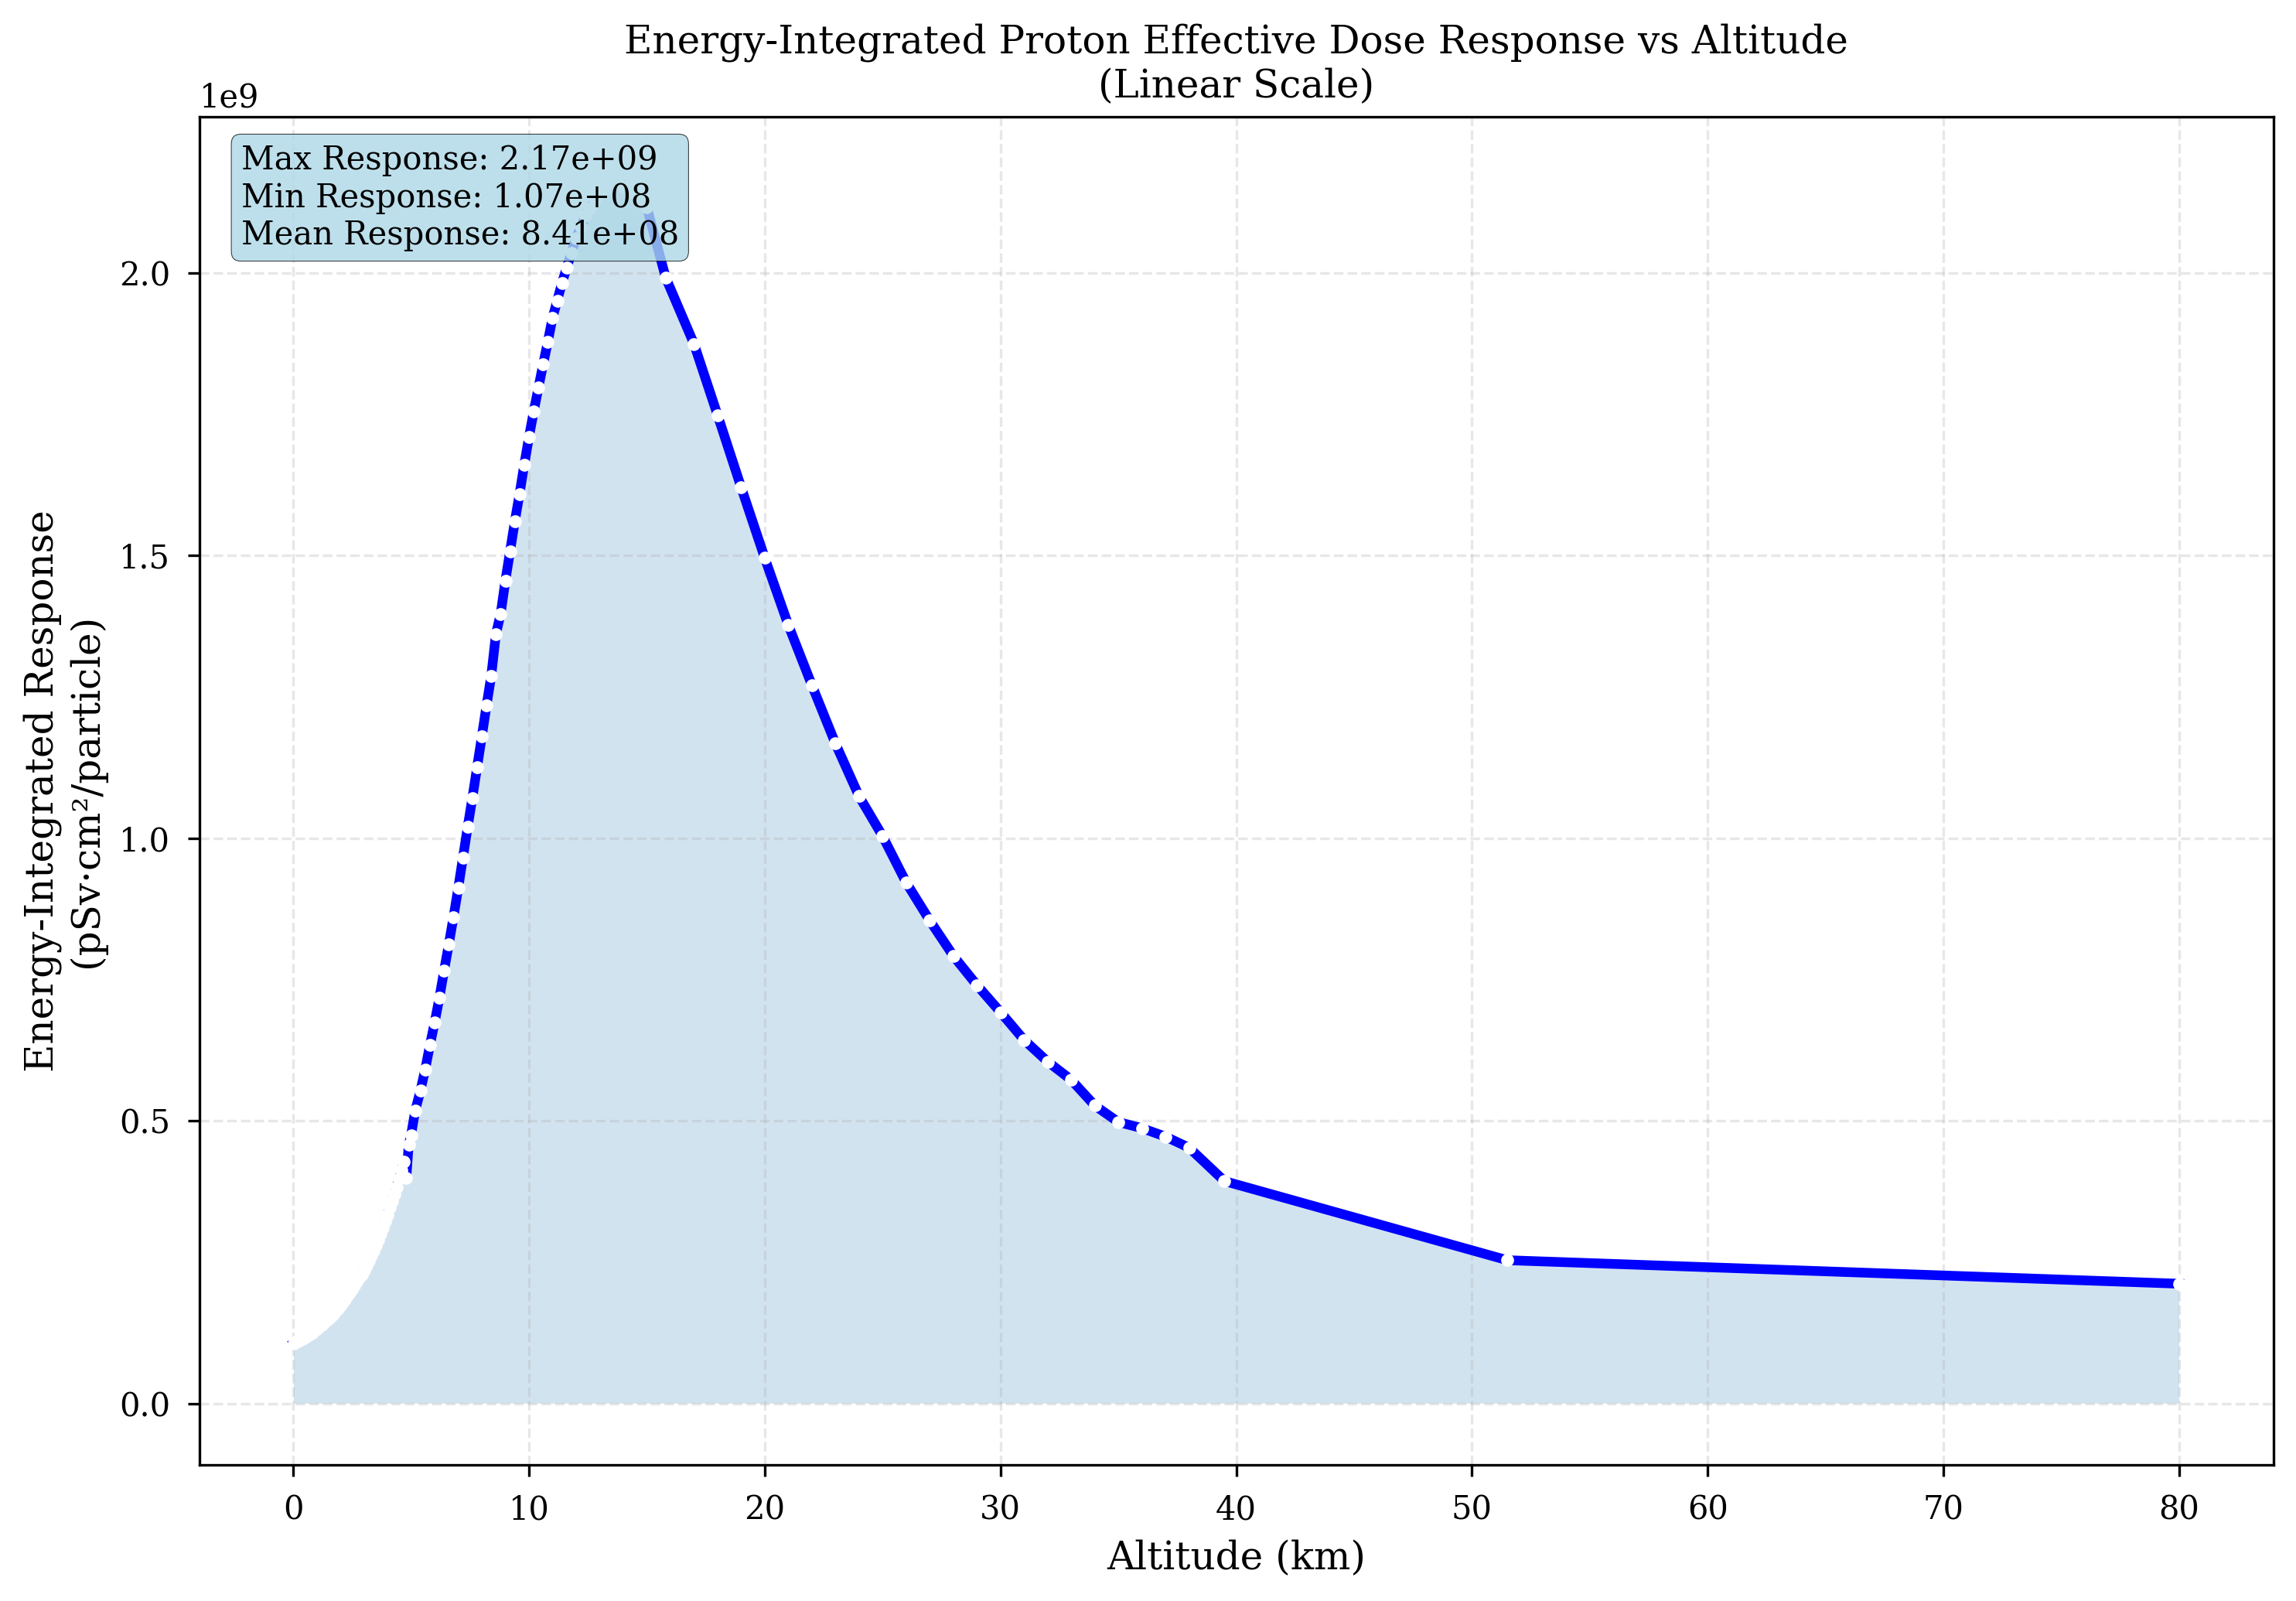

/tmp/ipykernel_268035/1919239996.py:295: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrated_response[alt_idx] = np.trapz(response_valid, energy_valid)


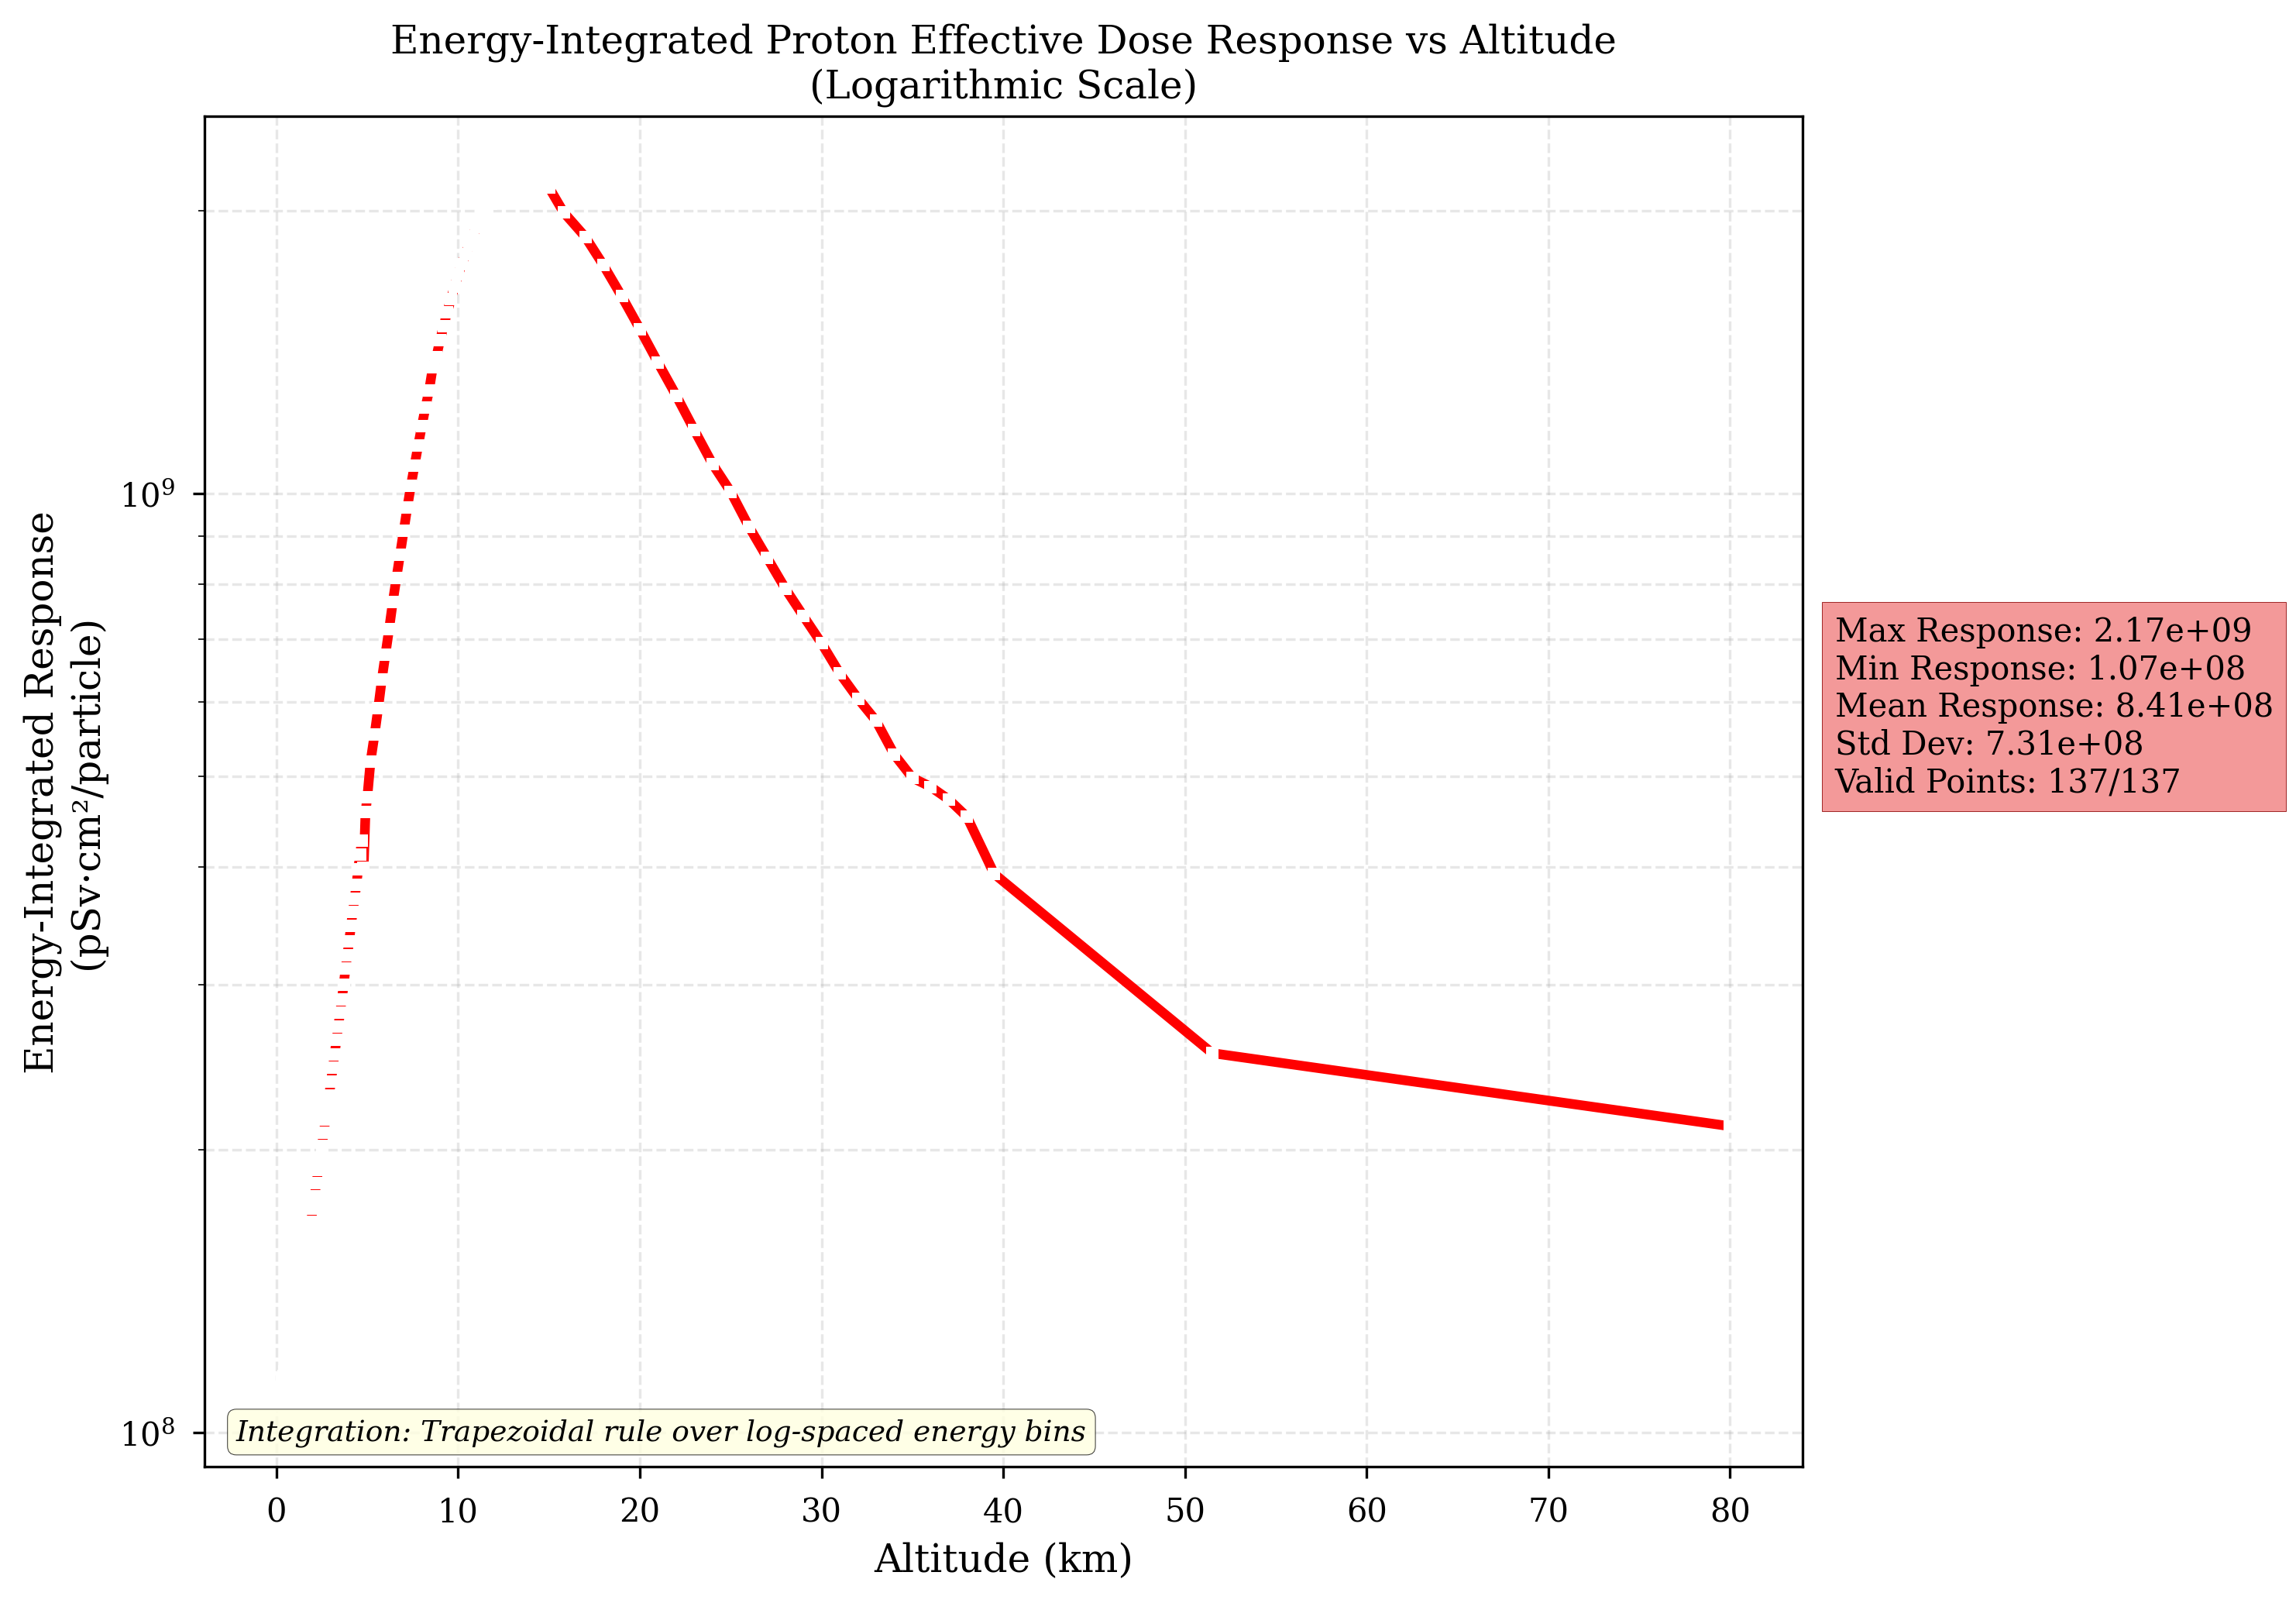

High-resolution plots saved as:
  - edose_energy_response.png
  - edose_altitude_response.png
  - edose_response_heatmap.png
  - edose_integrated_response_linear.png
  - edose_integrated_response_log.png

SCIENTIFIC NOTES:
- Altitude grid uses variable spacing (dense at low altitudes)
- Energy integration uses trapezoidal rule for accuracy
- Zero/negative values are properly masked in log plots
- Energy range spans ~1.3 MeV to ~316 GeV
- Response represents effective dose per incident proton


In [1]:
#!/usr/bin/env python3
"""
Script to plot edose yield function values for protons.

This script reads the response function data and visualizes how the edose 
(effective dose) response varies with energy at different altitudes.

SCIENTIFIC CORRECTIONS:
- Fixed altitude grid to use actual variable-spacing scheme from responseFileParameters.py
- Improved energy integration using trapezoidal rule for log-spaced bins
- Added proper handling of zero/negative values in log plots
- Enhanced statistical reporting and plot annotations
"""

import numpy as np
import matplotlib.pyplot as plt
import importlib.resources
from pathlib import Path
import sys
import datetime

# Set scientific style
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 300
})

# Try to import the package - handle different import scenarios
try:
    import atmosphericRadiationDoseAndFlux as ARDF
    from atmosphericRadiationDoseAndFlux import particle, particleResponse, units
    package_available = True
except ImportError:
    print("atmosphericRadiationDoseAndFlux package not found. Using direct file access.")
    package_available = False

def load_response_data():
    """Load the edose response data for protons."""
    if package_available:
        # Use the package's built-in data loading
        proton_particle = particle.Particle("proton")
        edose_response = particleResponse.DoseRateResponse(proton_particle, "edose")
        response_array = edose_response.particleResponseArray
    else:
        # Direct file access (assuming script is run from project root)
        response_file = Path("atmosphericRadiationDoseAndFlux/data/proton/edose.rpf")
        if not response_file.exists():
            print(f"Error: Response file not found at {response_file}")
            print("Please run this script from the project root directory.")
            sys.exit(1)
        response_array = np.genfromtxt(response_file)
    
    return response_array

def get_energy_bins():
    """Get the default energy bins used in the calculations."""
    # Default energy bins as defined in the codebase
    energy_bins = 10**(0.1*(np.array(range(1,52))-1)+1)
    energy_midpoints = (energy_bins[1:] + energy_bins[:-1]) / 2
    return energy_bins, energy_midpoints

def get_altitude_grid():
    """
    Get the actual altitude grid corresponding to the response file rows.
    
    This implements the complex altitude layering scheme used in the 
    atmospheric radiation response calculations, based on the logic
    from responseFileParameters.py.
    
    Returns
    -------
    np.ndarray
        Array of 137 altitude values in kilometers corresponding to each layer
    """
    altitudes_km = np.zeros(137)
    
    # Layer 1: 0.025 km
    altitudes_km[0] = 0.025
    
    # Layers 2-21: 0.025 to 1.025 km (50m spacing)
    for i in range(1, 21):
        altitudes_km[i] = 0.025 + (i-1) * 0.05 + 0.025  # midpoint of 50m layers
    
    # Layer 22: 1.15 km (midpoint between 1.025 and 1.15)
    altitudes_km[21] = 1.0875
    
    # Layers 23-61: 1.15 to 5.05 km (100m spacing)
    for i in range(22, 61):
        altitudes_km[i] = 1.15 + (i-22) * 0.1 + 0.05  # midpoint of 100m layers
    
    # Layer 62: 5.3 km (midpoint between 5.05 and 5.3)
    altitudes_km[61] = 5.175
    
    # Layers 63-111: 5.3 to 15.1 km (200m spacing)  
    for i in range(62, 111):
        altitudes_km[i] = 5.3 + (i-62) * 0.2 + 0.1  # midpoint of 200m layers
    
    # Layer 112: 16.5 km (midpoint between 15.1 and 16.5)
    altitudes_km[111] = 15.8
    
    # Layers 113-134: 16.5 to 38.5 km (1000m spacing)
    for i in range(112, 134):
        altitudes_km[i] = 16.5 + (i-112) * 1.0 + 0.5  # midpoint of 1000m layers
    
    # Layer 135: 40.5 km (midpoint between 38.5 and 40.5)
    altitudes_km[134] = 39.5
    
    # Layer 136: 62.5 km (midpoint between 40.5 and 62.5)
    altitudes_km[135] = 51.5
    
    # Layer 137: 97.5 km (midpoint between 62.5 and 97.5)
    altitudes_km[136] = 80.0
    
    return altitudes_km

def plot_energy_response(response_array, energy_midpoints, altitudes_km):
    """Plot response vs energy for selected altitudes"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)
    
    # Select representative altitudes across the full range
    selected_altitudes_idx = [0, 10, 20, 40, 61, 80, 111, 134, 136]
    selected_altitudes_km = [altitudes_km[i] for i in selected_altitudes_idx]
    colors = plt.cm.viridis(np.linspace(0, 1, len(selected_altitudes_idx)))
    
    for i, (alt_idx, color) in enumerate(zip(selected_altitudes_idx, colors)):
        response_values = response_array[alt_idx, :]
        # Mask zero/negative values for log plot
        mask = response_values > 0
        if np.any(mask):
            ax.loglog(energy_midpoints[mask], response_values[mask],
                     label=f'{selected_altitudes_km[i]:.1f} km',
                     color=color, linewidth=2, marker='o', markersize=3)
    
    ax.set_xlabel('Particle Energy (MeV)')
    ax.set_ylabel('Effective Dose Response\n(pSv·cm²/particle)')
    ax.set_title('Energy-Dependent Proton Effective Dose Response\nat Various Altitudes')
    ax.legend(title='Altitude', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.set_xlim(energy_midpoints[0], energy_midpoints[-1])
    
    # Add annotation about data source
    fig.text(0.02, 0.02, f'Generated: {datetime.datetime.now().strftime("%Y-%m-%d")}', 
             fontsize=8, style='italic')
    
    plt.tight_layout()
    return fig

def plot_altitude_response(response_array, energy_midpoints, altitudes_km):
    """Plot response vs altitude for selected energies"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)
    
    selected_energies_idx = [5, 15, 25, 35, 45, 49]  # Better energy sampling
    selected_energies = [energy_midpoints[i] for i in selected_energies_idx]
    colors = plt.cm.plasma(np.linspace(0, 1, len(selected_energies_idx)))
    
    for i, (en_idx, color) in enumerate(zip(selected_energies_idx, colors)):
        response_values = response_array[:, en_idx]
        # Mask zero/negative values for log plot
        mask = response_values > 0
        if np.any(mask):
            ax.semilogy(altitudes_km[mask], response_values[mask],
                       label=f'{selected_energies[i]:.0f} MeV',
                       color=color, linewidth=2, marker='o', markersize=3)
    
    ax.set_xlabel('Altitude (km)')
    ax.set_ylabel('Effective Dose Response\n(pSv·cm²/particle)')
    ax.set_title('Altitude-Dependent Proton Effective Dose Response\nat Various Energies')
    ax.legend(title='Energy', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    # Add annotation about altitude grid complexity
    ax.text(0.02, 0.98, 'Note: Altitude grid uses variable spacing\n(dense at low altitudes)', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    return fig

def plot_response_heatmap(response_array, energy_midpoints, altitudes_km):
    """Plot 2D heatmap of response distribution"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111)
    
    # Create meshgrid for plotting
    E_mesh, A_mesh = np.meshgrid(energy_midpoints, altitudes_km)
    
    # Handle zero/negative values before taking log
    response_array_masked = np.ma.masked_less_equal(response_array, 0)
    log_response = np.ma.log10(response_array_masked)
    
    # Create more detailed contour levels
    vmin, vmax = log_response.min(), log_response.max()
    levels = np.linspace(vmin, vmax, 100)
    
    im = ax.contourf(E_mesh, A_mesh, log_response, levels=levels, cmap='viridis', extend='both')
    ax.set_xscale('log')
    ax.set_xlabel('Particle Energy (MeV)')
    ax.set_ylabel('Altitude (km)')
    ax.set_title('Proton Effective Dose Response Function\n(log₁₀ scale)')
    
    # Add contour lines for better visualization
    contour_levels = np.linspace(vmin, vmax, 10)
    contours = ax.contour(E_mesh, A_mesh, log_response, levels=contour_levels,
                         colors='white', linewidths=0.5, alpha=0.7)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.1f')
    
    # Enhanced colorbar
    cbar = plt.colorbar(im, ax=ax, label='log₁₀(Response) [pSv·cm²/particle]', shrink=0.8)
    cbar.ax.tick_params(labelsize=10)
    
    # Add text annotations
    ax.text(0.02, 0.98, 'Variable altitude spacing\n(see altitude response plot)', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    plt.tight_layout()
    return fig

def plot_integrated_response_linear(response_array, energy_bins, energy_midpoints, altitudes_km):
    """
    Plot integrated response with proper energy integration.
    
    Uses trapezoidal rule for more accurate integration over logarithmic energy bins.
    """
    integrated_response = np.zeros(len(altitudes_km))
    
    # Handle zero/negative values
    response_array_masked = np.ma.masked_less_equal(response_array, 0)
    
    for alt_idx in range(len(altitudes_km)):
        # Use trapezoidal rule with energy midpoints for more accurate integration
        # This accounts for the logarithmic spacing of energy bins
        response_at_alt = response_array_masked[alt_idx, :]
        
        if np.ma.count(response_at_alt) > 1:  # Ensure we have valid data
            # Trapezoidal integration over log-spaced energy bins
            valid_mask = ~response_at_alt.mask
            if np.sum(valid_mask) > 1:
                energy_valid = energy_midpoints[valid_mask]
                response_valid = response_at_alt.compressed()
                # Use trapezoidal rule
                integrated_response[alt_idx] = np.trapz(response_valid, energy_valid)
            else:
                integrated_response[alt_idx] = 0.0
        else:
            integrated_response[alt_idx] = 0.0
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)
    
    # Mask zero values for plotting
    mask = integrated_response > 0
    ax.plot(altitudes_km[mask], integrated_response[mask], 'b-', linewidth=3, 
            marker='o', markersize=4, markerfacecolor='white', markeredgecolor='blue')
    ax.set_xlabel('Altitude (km)')
    ax.set_ylabel('Energy-Integrated Response\n(pSv·cm²/particle)')
    ax.set_title('Energy-Integrated Proton Effective Dose Response vs Altitude\n(Linear Scale)')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.fill_between(altitudes_km[mask], integrated_response[mask], alpha=0.2)
    
    # Add statistical information
    stats_text = (f'Max Response: {integrated_response[mask].max():.2e}\n'
                 f'Min Response: {integrated_response[mask].min():.2e}\n'
                 f'Mean Response: {integrated_response[mask].mean():.2e}')
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    return fig

def plot_integrated_response_log(response_array, energy_bins, energy_midpoints, altitudes_km):
    """Plot integrated response with log scale and proper integration"""
    integrated_response = np.zeros(len(altitudes_km))
    
    # Handle zero/negative values
    response_array_masked = np.ma.masked_less_equal(response_array, 0)
    
    for alt_idx in range(len(altitudes_km)):
        response_at_alt = response_array_masked[alt_idx, :]
        
        if np.ma.count(response_at_alt) > 1:
            valid_mask = ~response_at_alt.mask
            if np.sum(valid_mask) > 1:
                energy_valid = energy_midpoints[valid_mask]
                response_valid = response_at_alt.compressed()
                integrated_response[alt_idx] = np.trapz(response_valid, energy_valid)
            else:
                integrated_response[alt_idx] = 0.0
        else:
            integrated_response[alt_idx] = 0.0
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111)
    
    # Mask zero values for log plotting
    mask = integrated_response > 0
    ax.semilogy(altitudes_km[mask], integrated_response[mask], 'r-', linewidth=3,
                marker='s', markersize=4, markerfacecolor='white', markeredgecolor='red')
    ax.set_xlabel('Altitude (km)')
    ax.set_ylabel('Energy-Integrated Response\n(pSv·cm²/particle)')
    ax.set_title('Energy-Integrated Proton Effective Dose Response vs Altitude\n(Logarithmic Scale)')
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    
    # Enhanced statistical information
    valid_responses = integrated_response[mask]
    stats_text = (f'Max Response: {valid_responses.max():.2e}\n'
                 f'Min Response: {valid_responses.min():.2e}\n'
                 f'Mean Response: {valid_responses.mean():.2e}\n'
                 f'Std Dev: {valid_responses.std():.2e}\n'
                 f'Valid Points: {len(valid_responses)}/137')
    ax.text(1.02, 0.5, stats_text, transform=ax.transAxes, fontsize=10,
            bbox=dict(facecolor='lightcoral', alpha=0.8, edgecolor='darkred'))
    
    # Add information about integration method
    ax.text(0.02, 0.02, 'Integration: Trapezoidal rule over log-spaced energy bins', 
            transform=ax.transAxes, fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    return fig

def print_specific_values(response_array, energy_midpoints, altitudes_km):
    """Print response values at specific altitudes and energies"""
    # Find closest indices for 40kft (approximately 12.2 km)
    target_alt = 12.2  # km
    alt_idx = np.abs(altitudes_km - target_alt).argmin()
    
    # Find closest indices for specified energies
    target_energies = np.array([100, 500, 1000, 5000])  # MeV
    energy_indices = [np.abs(energy_midpoints - e).argmin() for e in target_energies]
    
    print("\nResponse values at approximately 40,000 ft (12.2 km):")
    print(f"Actual altitude: {altitudes_km[alt_idx]:.2f} km")
    print("\nEnergy (GeV/nucleon) | Response (pSv·cm²/particle)")
    print("-" * 50)
    
    for e_idx, energy in zip(energy_indices, target_energies/1000):  # Convert to GeV
        response = response_array[alt_idx, e_idx]
        print(f"{energy:16.1f} | {response:30.2e}")

def main():
    """Main function to generate plots."""
    print("Loading edose response data for protons...")
    
    try:
        response_array = load_response_data()
        energy_bins, energy_midpoints = get_energy_bins()
        altitudes_km = get_altitude_grid()
        
        print(f"Response array shape: {response_array.shape}")
        print(f"Energy range: {energy_midpoints[0]:.2f} - {energy_midpoints[-1]:.2e} MeV")
        print(f"Altitude range: {altitudes_km[0]:.3f} - {altitudes_km[-1]:.1f} km")
        print(f"Number of zero/negative values: {np.sum(response_array <= 0)}")
        
        # Print specific values at 40kft and selected energies
        print_specific_values(response_array, energy_midpoints, altitudes_km)
        
        # Generate and save individual plots
        print("\nGenerating energy response plot...")
        fig1 = plot_energy_response(response_array, energy_midpoints, altitudes_km)
        fig1.savefig('edose_energy_response.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Generating altitude response plot...")
        fig2 = plot_altitude_response(response_array, energy_midpoints, altitudes_km)
        fig2.savefig('edose_altitude_response.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Generating response heatmap...")
        fig3 = plot_response_heatmap(response_array, energy_midpoints, altitudes_km)
        fig3.savefig('edose_response_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("Generating integrated response plots...")
        fig4 = plot_integrated_response_linear(response_array, energy_bins, energy_midpoints, altitudes_km)
        fig4.savefig('edose_integrated_response_linear.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        fig5 = plot_integrated_response_log(response_array, energy_bins, energy_midpoints, altitudes_km)
        fig5.savefig('edose_integrated_response_log.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("High-resolution plots saved as:")
        print("  - edose_energy_response.png")
        print("  - edose_altitude_response.png") 
        print("  - edose_response_heatmap.png")
        print("  - edose_integrated_response_linear.png")
        print("  - edose_integrated_response_log.png")
        
        print("\nSCIENTIFIC NOTES:")
        print("- Altitude grid uses variable spacing (dense at low altitudes)")
        print("- Energy integration uses trapezoidal rule for accuracy")
        print("- Zero/negative values are properly masked in log plots")
        print("- Energy range spans ~1.3 MeV to ~316 GeV")
        print("- Response represents effective dose per incident proton")
        
    except Exception as e:
        print(f"Error: {e}")
        print("Make sure you have the required dependencies (numpy, matplotlib) installed.")
        print("If running without the package, ensure you're in the project root directory.")

if __name__ == "__main__":
    main()

In [2]:
def get_weighting_factor(energy_mev, altitude_km, response_array, energy_midpoints, altitudes_km):
    """
    Get the weighting factor for a specific energy and altitude by interpolating the response array.
    
    Parameters:
    -----------
    energy_mev : float
        Energy in MeV
    altitude_km : float
        Altitude in km
    response_array : ndarray
        2D array containing response values
    energy_midpoints : ndarray
        Array of energy bin midpoints
    altitudes_km : ndarray
        Array of altitude values
    
    Returns:
    --------
    float
        Interpolated weighting factor
    """
    from scipy.interpolate import RegularGridInterpolator
    
    # Create interpolator function
    interpolator = RegularGridInterpolator(
        (energy_midpoints, altitudes_km),
        response_array.T,
        bounds_error=False,
        fill_value=None
    )
    
    # Get interpolated weight
    weight = float(interpolator(energy_mev, altitude_km))
    
    return weight



NameError: name 'response_array' is not defined

In [ ]:
Sv cm2 sr nuc-1

In [5]:
10**(0.1*(np.array(range(1,52))-1)+1)

array([1.00000000e+01, 1.25892541e+01, 1.58489319e+01, 1.99526231e+01,
       2.51188643e+01, 3.16227766e+01, 3.98107171e+01, 5.01187234e+01,
       6.30957344e+01, 7.94328235e+01, 1.00000000e+02, 1.25892541e+02,
       1.58489319e+02, 1.99526231e+02, 2.51188643e+02, 3.16227766e+02,
       3.98107171e+02, 5.01187234e+02, 6.30957344e+02, 7.94328235e+02,
       1.00000000e+03, 1.25892541e+03, 1.58489319e+03, 1.99526231e+03,
       2.51188643e+03, 3.16227766e+03, 3.98107171e+03, 5.01187234e+03,
       6.30957344e+03, 7.94328235e+03, 1.00000000e+04, 1.25892541e+04,
       1.58489319e+04, 1.99526231e+04, 2.51188643e+04, 3.16227766e+04,
       3.98107171e+04, 5.01187234e+04, 6.30957344e+04, 7.94328235e+04,
       1.00000000e+05, 1.25892541e+05, 1.58489319e+05, 1.99526231e+05,
       2.51188643e+05, 3.16227766e+05, 3.98107171e+05, 5.01187234e+05,
       6.30957344e+05, 7.94328235e+05, 1.00000000e+06])

In [12]:
from atmosphericRadiationDoseAndFlux.doseAndFluxCalculator import calculate_from_energy_spec

AttributeError: module 'pkgutil' has no attribute 'ImpImporter'